<a href="https://www.kaggle.com/code/omborse771924/airline-satisfaction-data-eda?scriptVersionId=344436816" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv')

In [3]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

DATASET LOADED
Rows    : 129880
Columns : 22

COLUMN NAMES
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

HEAD
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight wif

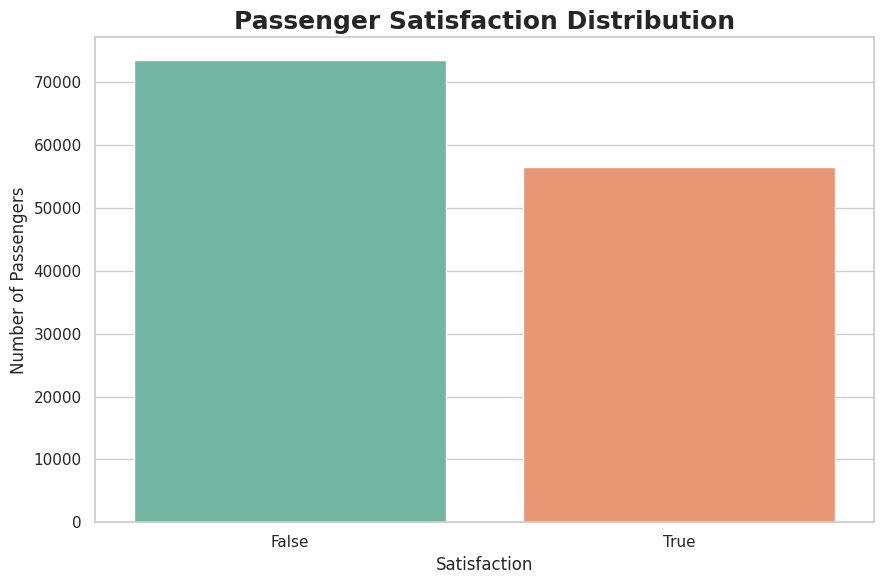

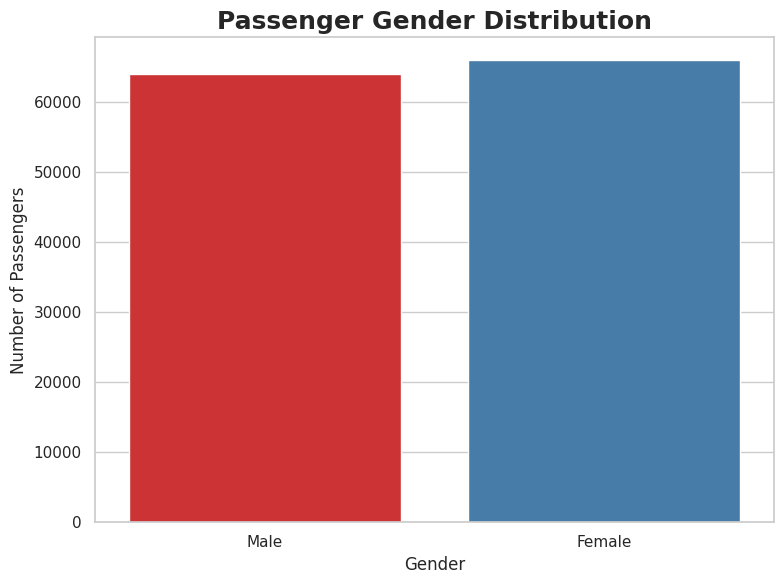

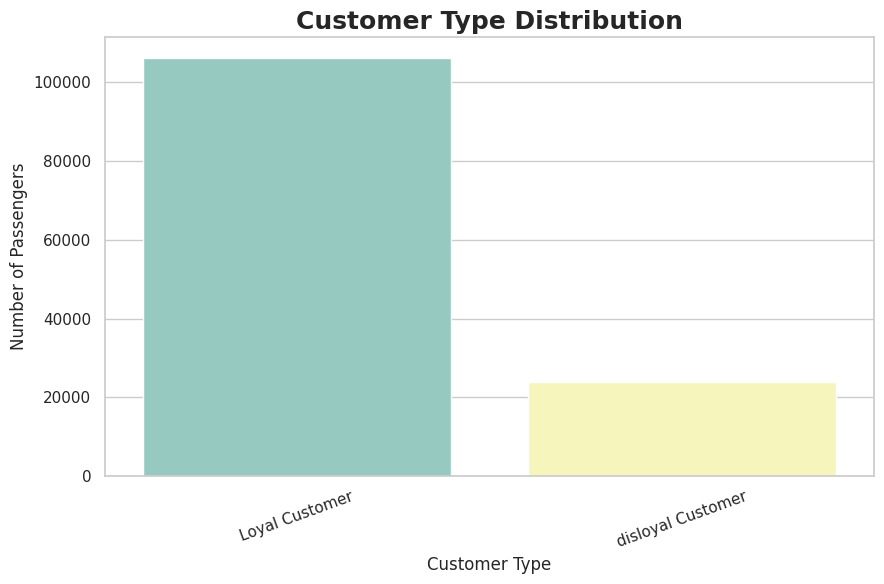

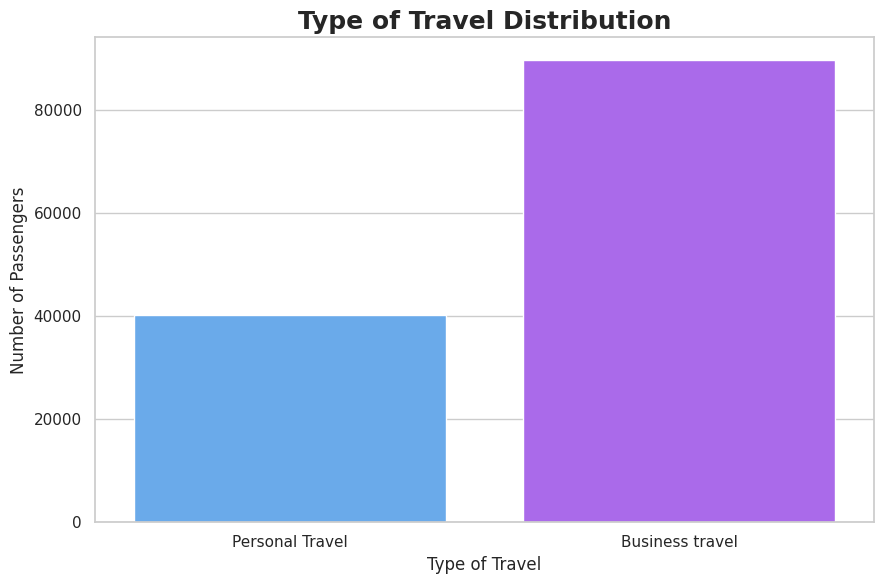

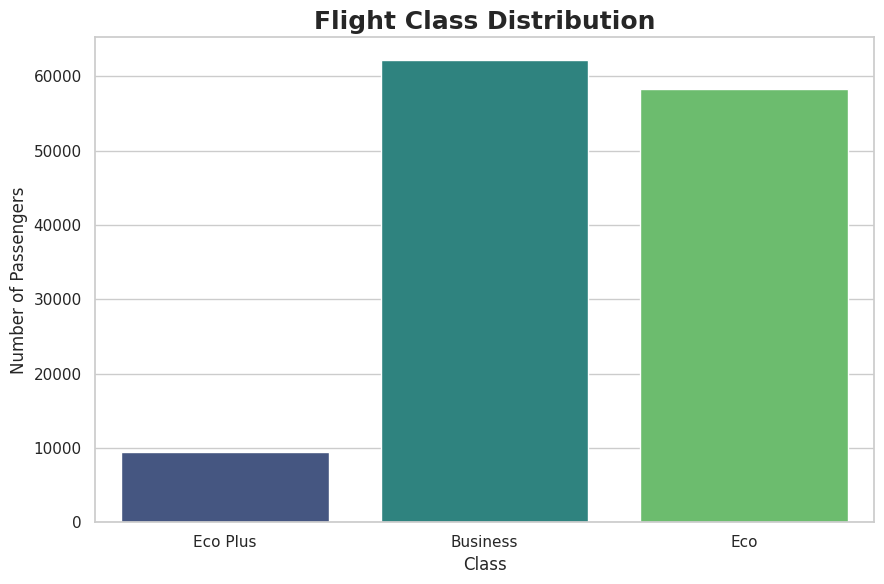

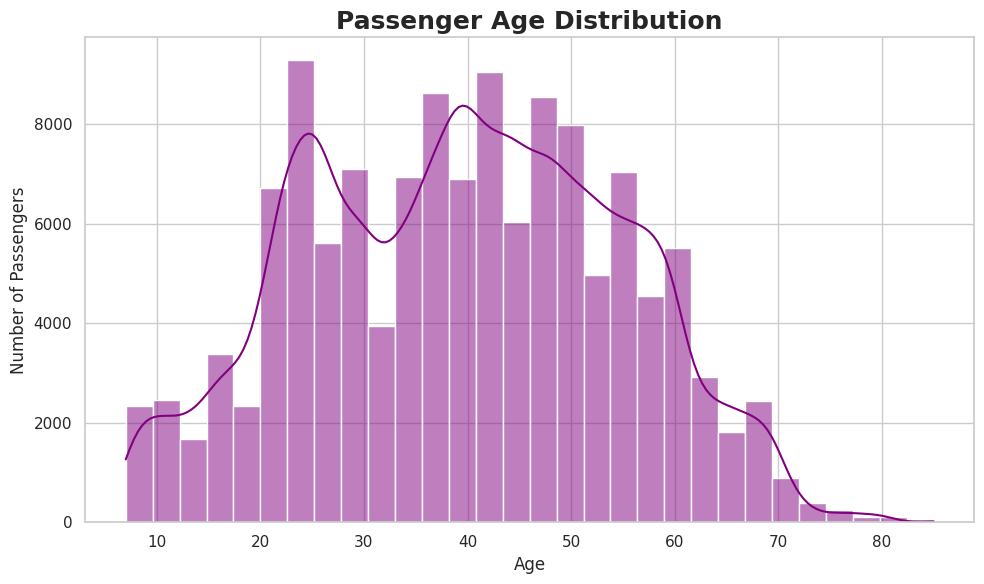

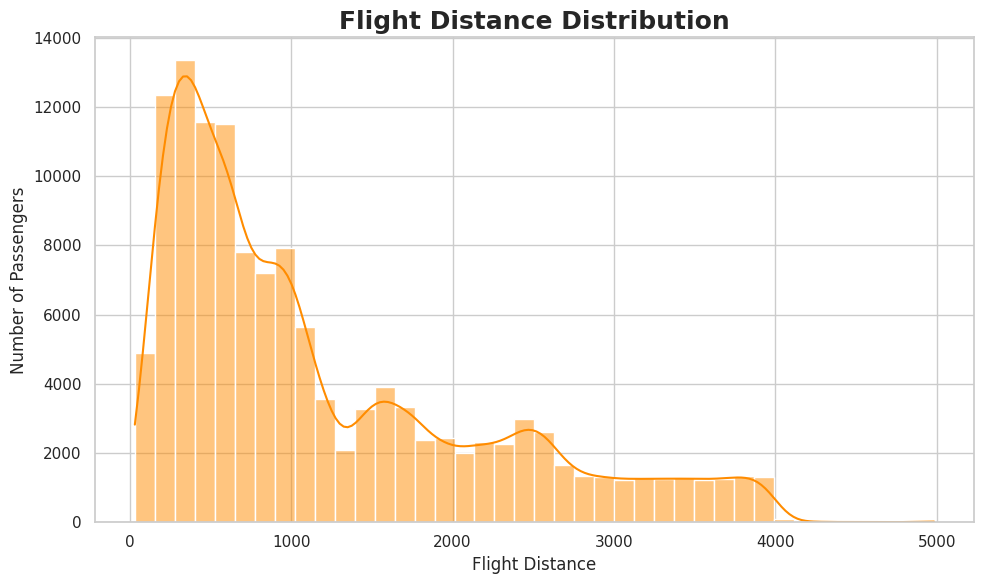

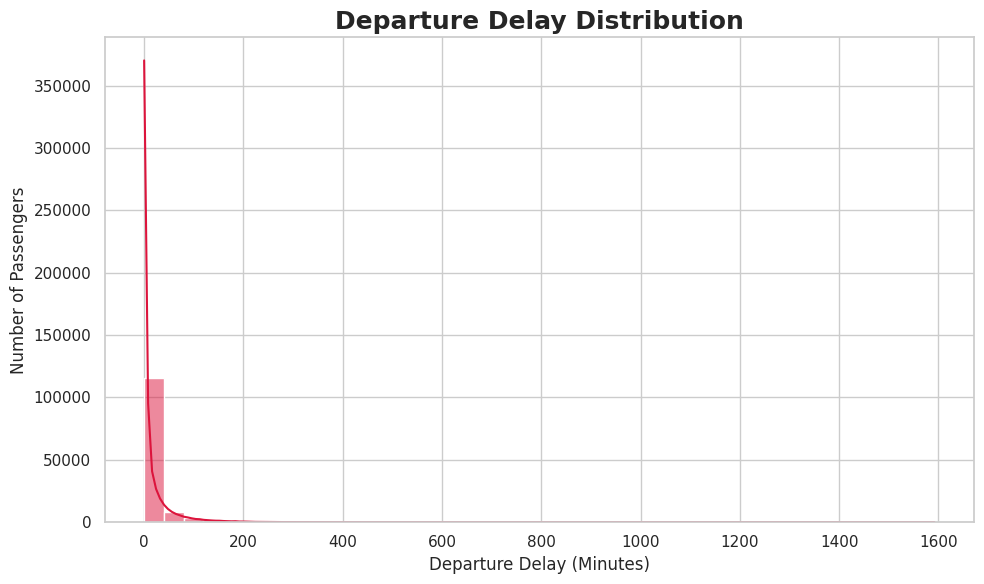

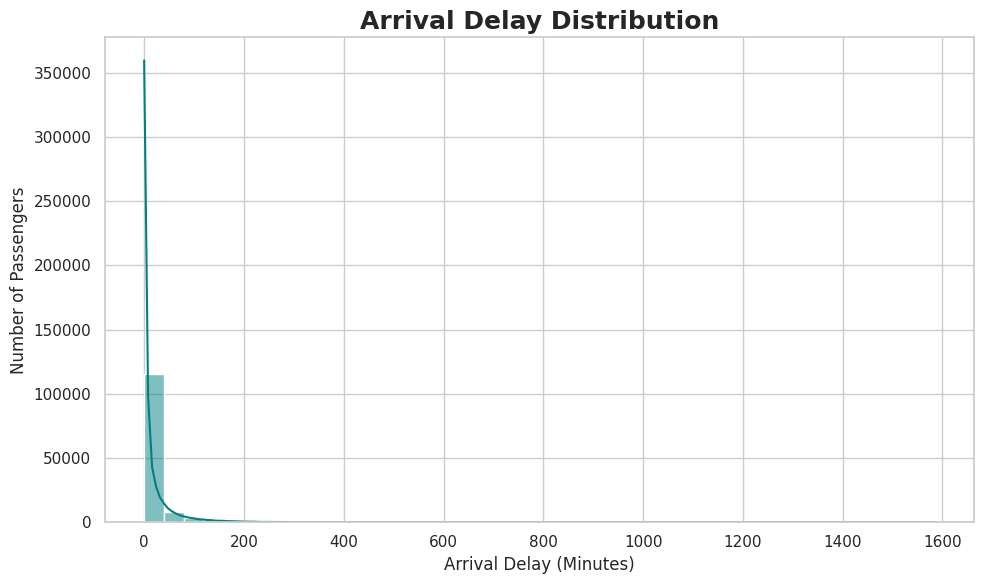

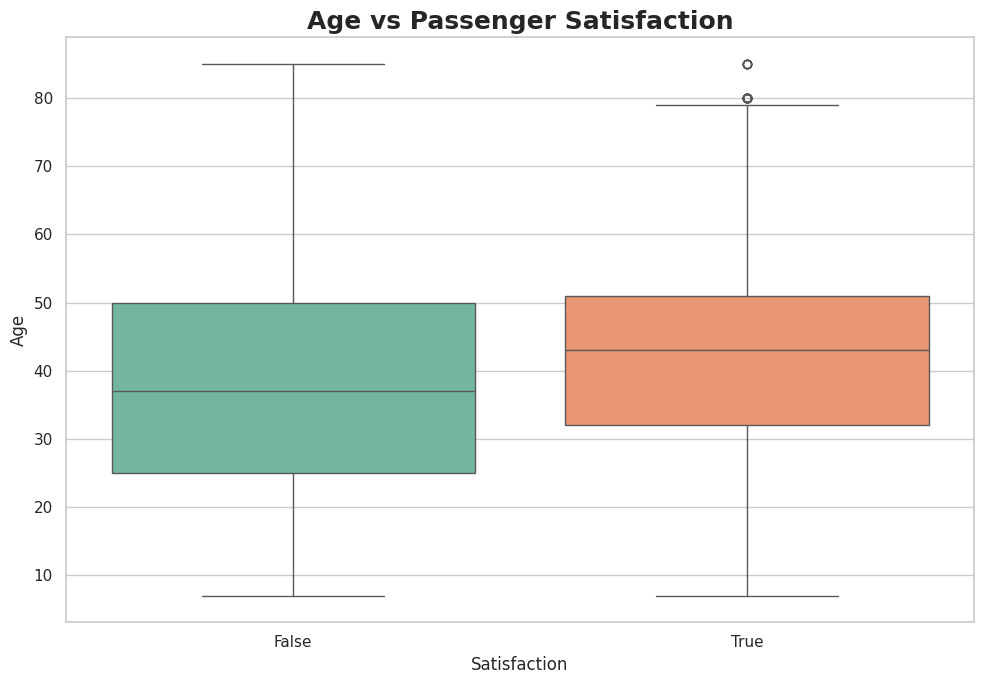

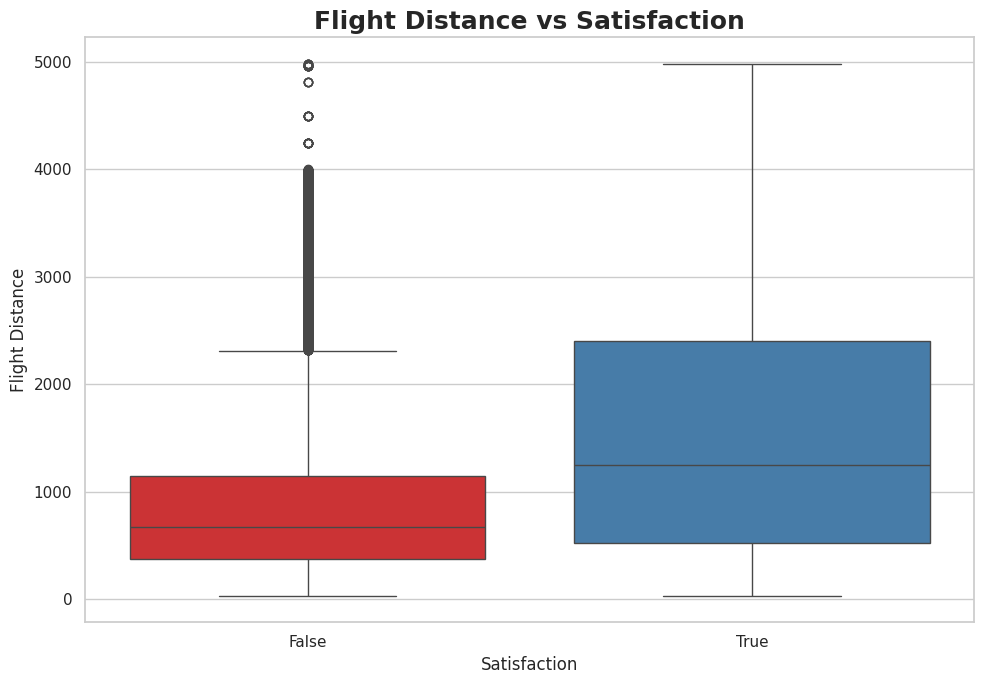

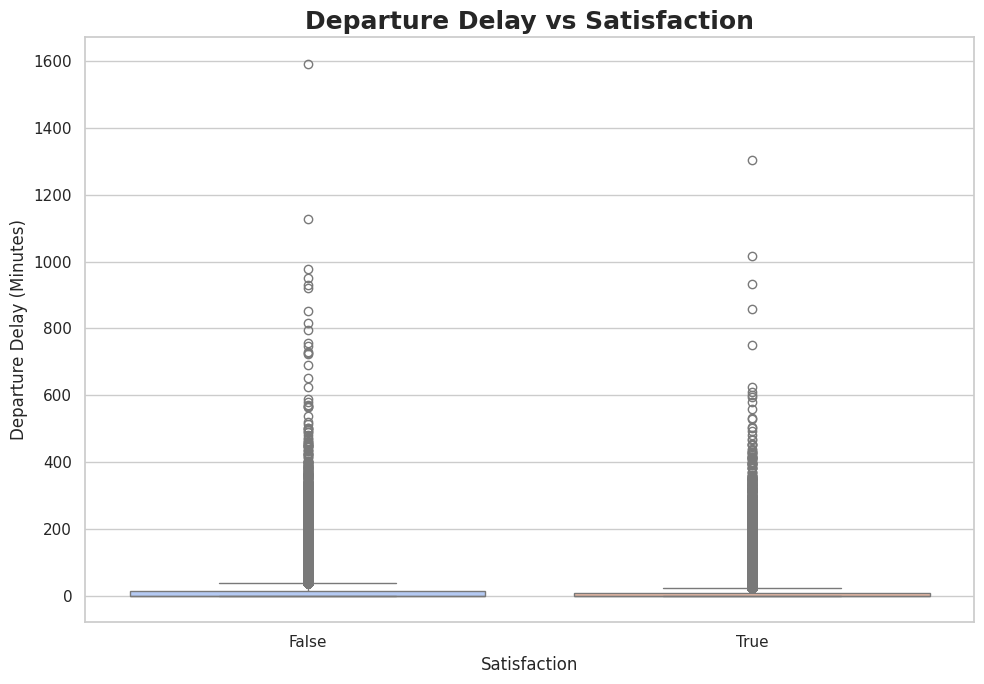

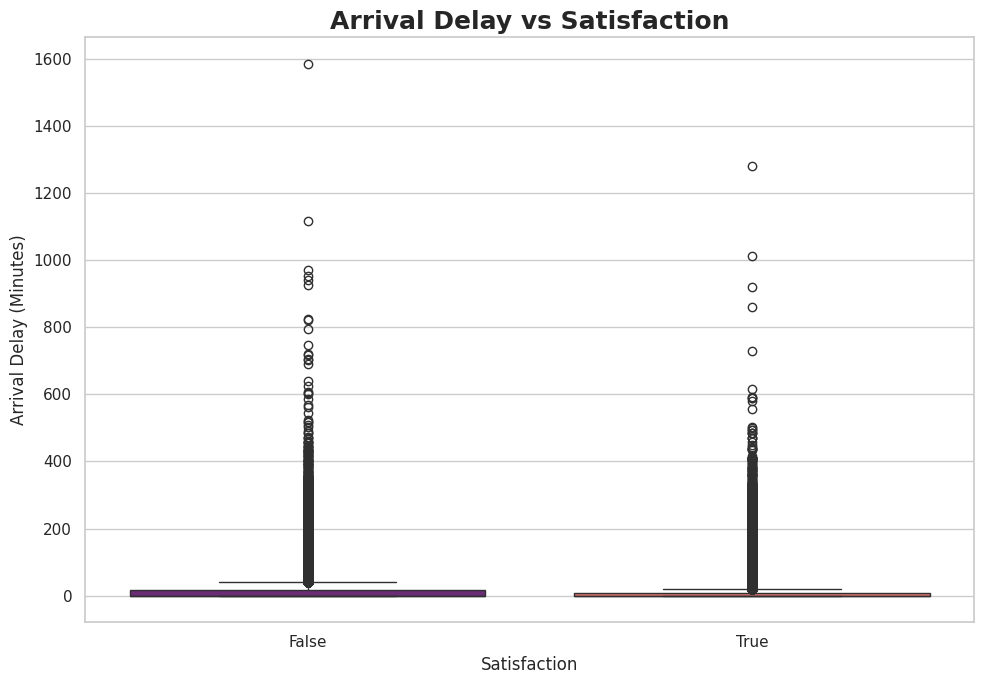

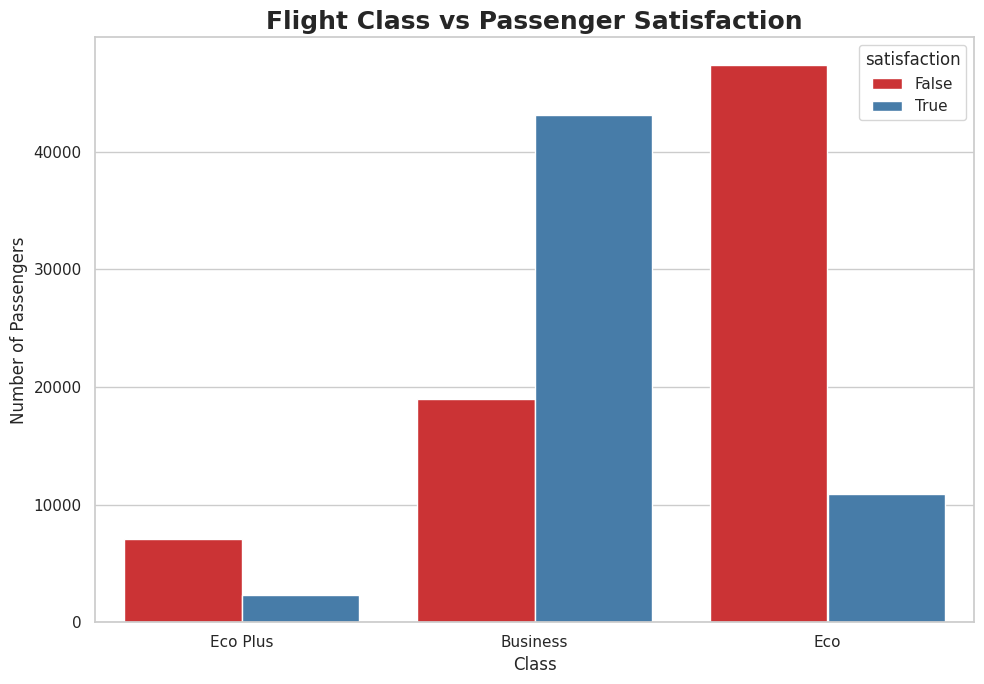

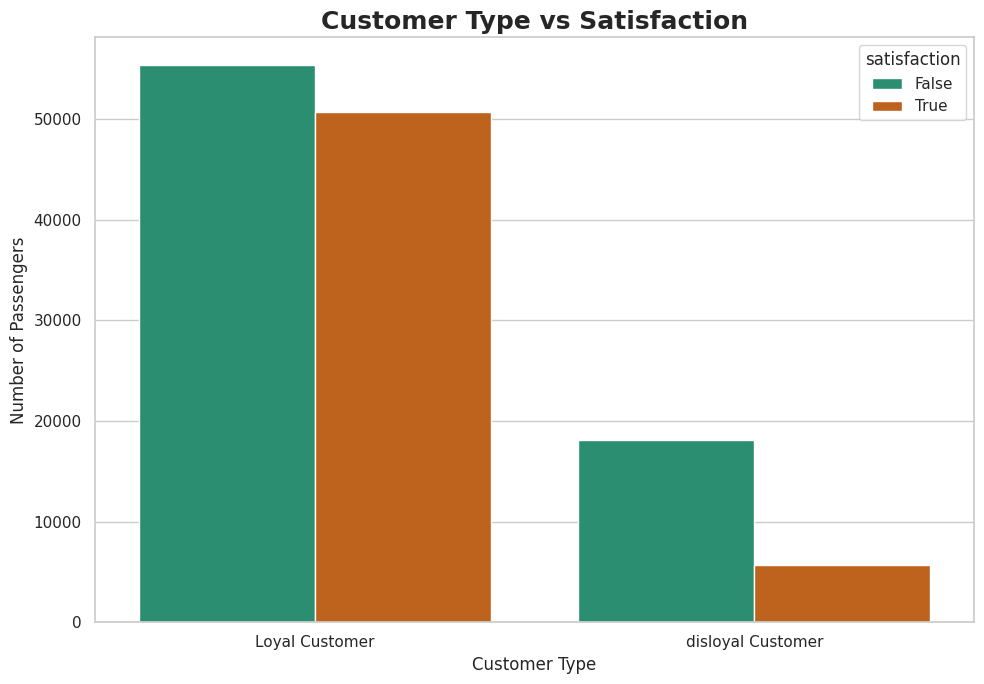

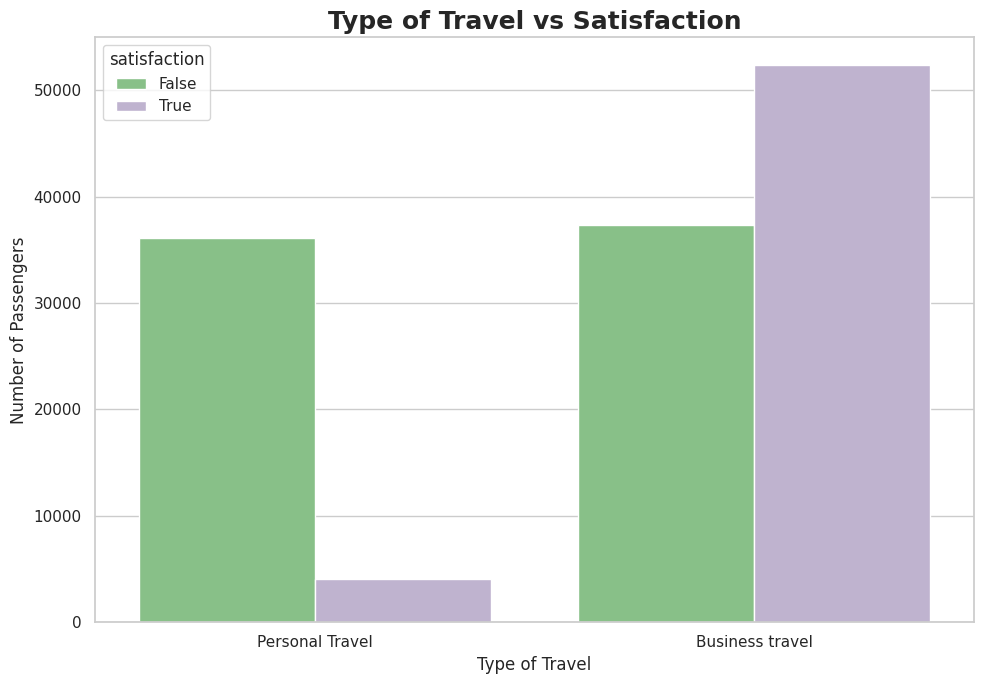

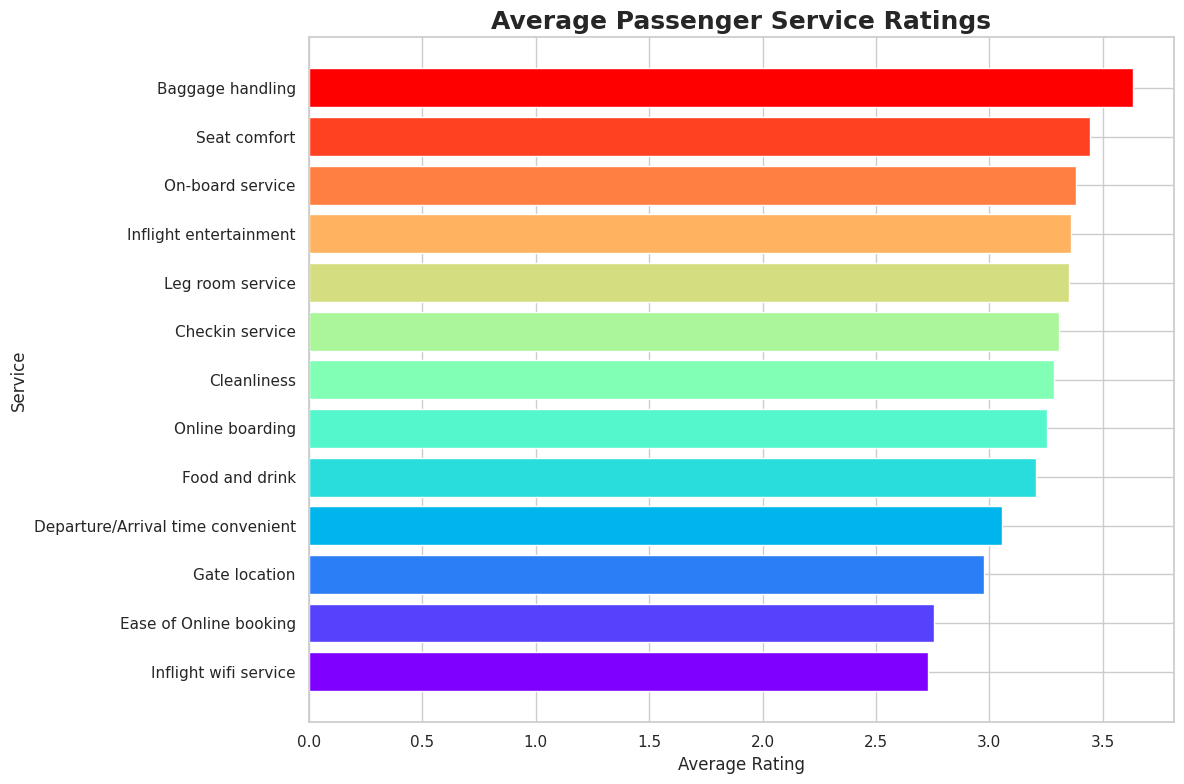

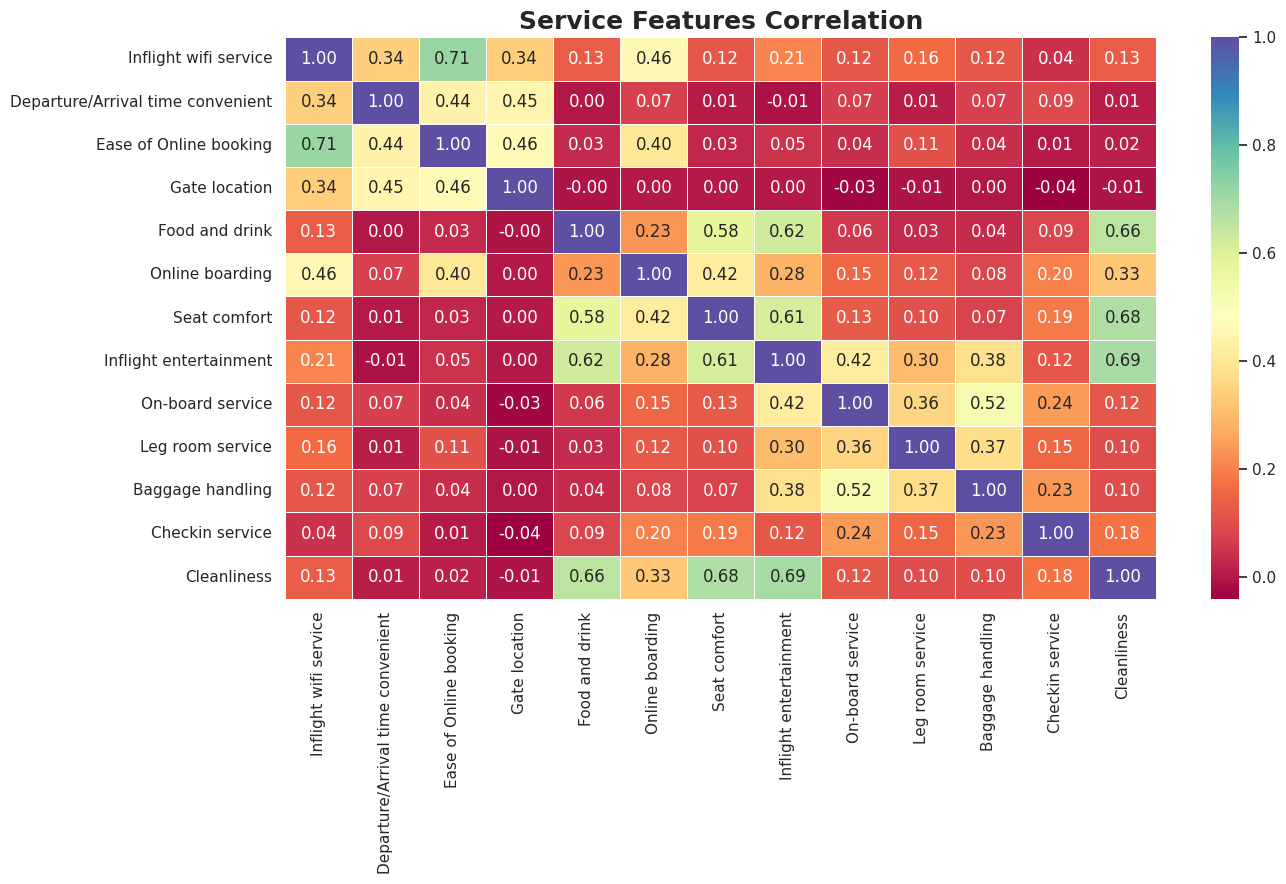

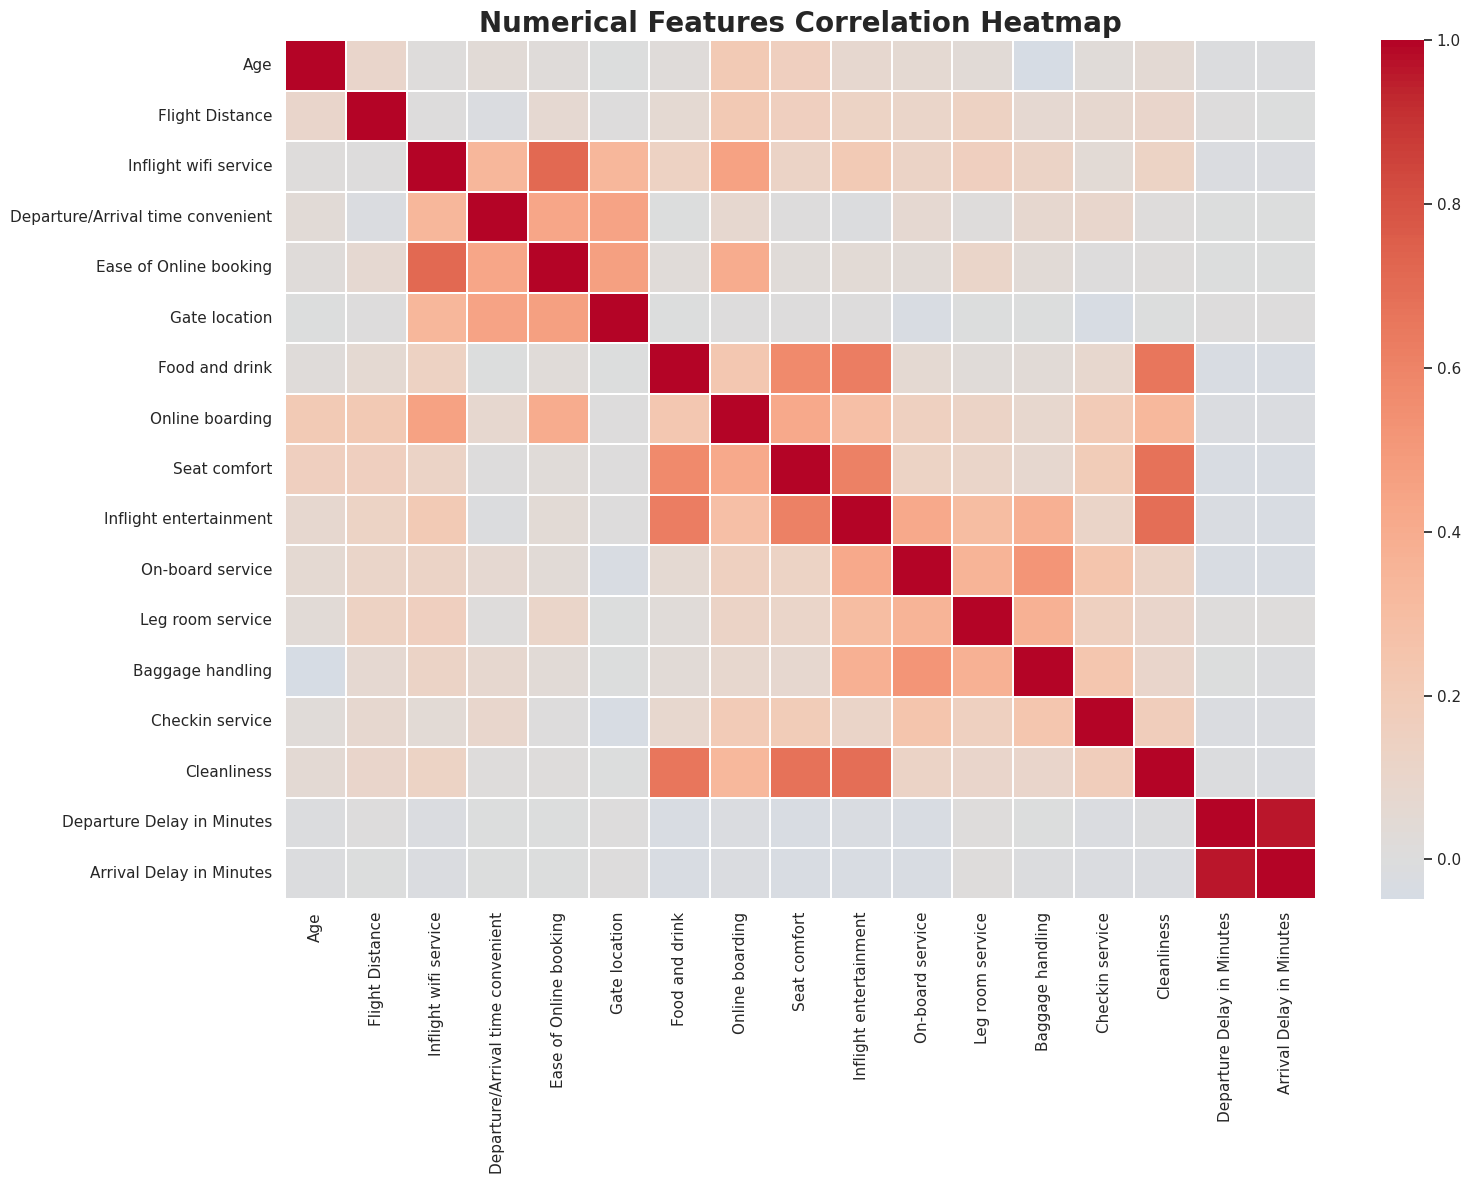

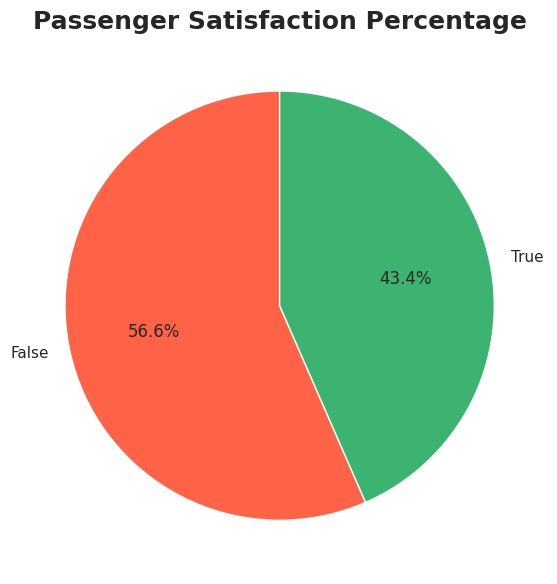


FINAL EDA SUMMARY
Final Shape: (129880, 22)
Remaining NULL Values: 0
Remaining Duplicate Rows: 0

Satisfaction Distribution:
satisfaction
False    73452
True     56428
Name: count, dtype: int64

Numerical Columns:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical Columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

EDA COMPLETED SUCCESSFULLY!


In [4]:
# ============================================================
# AIRLINE PASSENGER SATISFACTION - COMPLETE EDA
# NULL VALUES + DUPLICATES + VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Visualization style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")

# ============================================================
# 1. COPY DATASET
# ============================================================

data = df.copy()

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])


# ============================================================
# 2. COLUMN NAMES
# ============================================================

print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)

print(data.columns.tolist())


# ============================================================
# 3. FIRST 5 ROWS
# ============================================================

print("\n" + "=" * 80)
print("HEAD")
print("=" * 80)

print(data.head())


# ============================================================
# 4. LAST 5 ROWS
# ============================================================

print("\n" + "=" * 80)
print("TAIL")
print("=" * 80)

print(data.tail())


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("DATASET INFO")
print("=" * 80)

data.info()


# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

print(data.describe(include="all").T)


# ============================================================
# 7. DATA TYPES
# ============================================================

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)

print(data.dtypes)


# ============================================================
# 8. INITIAL NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("INITIAL NULL VALUES")
print("=" * 80)

null_counts = data.isnull().sum()

print(
    null_counts[
        null_counts > 0
    ].sort_values(
        ascending=False
    )
)


# ============================================================
# 9. NULL VALUE PERCENTAGE
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUE PERCENTAGE")
print("=" * 80)

null_percentage = (
    data.isnull().sum()
    / len(data)
    * 100
)

print(
    null_percentage[
        null_percentage > 0
    ].sort_values(
        ascending=False
    )
)


# ============================================================
# 10. HANDLE NULL VALUES
# ============================================================

# Numeric columns -> median
numeric_columns = data.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    if data[col].isnull().sum() > 0:

        data[col] = data[col].fillna(
            data[col].median()
        )


# Categorical columns -> mode
categorical_columns = data.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_columns:

    if data[col].isnull().sum() > 0:

        mode_value = data[col].mode()

        if len(mode_value) > 0:

            data[col] = data[col].fillna(
                mode_value.iloc[0]
            )

        else:

            data[col] = data[col].fillna(
                "Unknown"
            )


# ============================================================
# 11. CHECK NULL VALUES AFTER HANDLING
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES AFTER HANDLING")
print("=" * 80)

remaining_nulls = data.isnull().sum()

print(
    remaining_nulls[
        remaining_nulls > 0
    ]
)

print(
    "\nTotal remaining null values:",
    data.isnull().sum().sum()
)


# ============================================================
# 12. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 80)
print("DUPLICATE ANALYSIS")
print("=" * 80)

duplicate_count = data.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)


# ============================================================
# 13. REMOVE DUPLICATES
# ============================================================

if duplicate_count > 0:

    data = data.drop_duplicates()

    data = data.reset_index(
        drop=True
    )

    print(
        "Duplicates removed successfully."
    )

else:

    print(
        "No duplicate rows found."
    )


print(
    "Shape after duplicate handling:",
    data.shape
)


# ============================================================
# 14. FINAL DATASET CHECK
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATASET CHECK")
print("=" * 80)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

print(
    "\nTotal NULL values:",
    data.isnull().sum().sum()
)

print(
    "Total duplicates:",
    data.duplicated().sum()
)


# ============================================================
# 15. SATISFACTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="satisfaction",
    hue="satisfaction",
    palette="Set2",
    legend=False
)

plt.title(
    "Passenger Satisfaction Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 16. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="Gender",
    hue="Gender",
    palette="Set1",
    legend=False
)

plt.title(
    "Passenger Gender Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 17. CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="Customer Type",
    hue="Customer Type",
    palette="Set3",
    legend=False
)

plt.title(
    "Customer Type Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Customer Type")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# ============================================================
# 18. TYPE OF TRAVEL
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="Type of Travel",
    hue="Type of Travel",
    palette="cool",
    legend=False
)

plt.title(
    "Type of Travel Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Type of Travel")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 19. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="Class",
    hue="Class",
    palette="viridis",
    legend=False
)

plt.title(
    "Flight Class Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 20. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data["Age"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title(
    "Passenger Age Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 21. FLIGHT DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data["Flight Distance"],
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title(
    "Flight Distance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Flight Distance")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 22. DEPARTURE DELAY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data["Departure Delay in Minutes"],
    bins=40,
    kde=True,
    color="crimson"
)

plt.title(
    "Departure Delay Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 23. ARRIVAL DELAY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data["Arrival Delay in Minutes"],
    bins=40,
    kde=True,
    color="teal"
)

plt.title(
    "Arrival Delay Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 24. AGE VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=data,
    x="satisfaction",
    y="Age",
    hue="satisfaction",
    palette="Set2",
    legend=False
)

plt.title(
    "Age vs Passenger Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction")
plt.ylabel("Age")

plt.tight_layout()
plt.show()


# ============================================================
# 25. FLIGHT DISTANCE VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=data,
    x="satisfaction",
    y="Flight Distance",
    hue="satisfaction",
    palette="Set1",
    legend=False
)

plt.title(
    "Flight Distance vs Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")

plt.tight_layout()
plt.show()


# ============================================================
# 26. DEPARTURE DELAY VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=data,
    x="satisfaction",
    y="Departure Delay in Minutes",
    hue="satisfaction",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Departure Delay vs Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction")
plt.ylabel("Departure Delay (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 27. ARRIVAL DELAY VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=data,
    x="satisfaction",
    y="Arrival Delay in Minutes",
    hue="satisfaction",
    palette="magma",
    legend=False
)

plt.title(
    "Arrival Delay vs Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction")
plt.ylabel("Arrival Delay (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 28. CLASS VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.countplot(
    data=data,
    x="Class",
    hue="satisfaction",
    palette="Set1"
)

plt.title(
    "Flight Class vs Passenger Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 29. CUSTOMER TYPE VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.countplot(
    data=data,
    x="Customer Type",
    hue="satisfaction",
    palette="Dark2"
)

plt.title(
    "Customer Type vs Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Customer Type")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 30. TYPE OF TRAVEL VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.countplot(
    data=data,
    x="Type of Travel",
    hue="satisfaction",
    palette="Accent"
)

plt.title(
    "Type of Travel vs Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Type of Travel")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


# ============================================================
# 31. SERVICE RATINGS
# ============================================================

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness"
]

existing_service_columns = [
    col
    for col in service_columns
    if col in data.columns
]

if len(existing_service_columns) > 0:

    service_means = (
        data[existing_service_columns]
        .mean()
        .sort_values()
    )

    plt.figure(
        figsize=(12, 8)
    )

    plt.barh(
        service_means.index,
        service_means.values,
        color=plt.cm.rainbow(
            np.linspace(
                0,
                1,
                len(service_means)
            )
        )
    )

    plt.title(
        "Average Passenger Service Ratings",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "Average Rating"
    )

    plt.ylabel(
        "Service"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. SERVICE RATINGS HEATMAP
# ============================================================

if len(existing_service_columns) > 0:

    plt.figure(
        figsize=(14, 9)
    )

    service_corr = data[
        existing_service_columns
    ].corr()

    sns.heatmap(
        service_corr,
        cmap="Spectral",
        annot=True,
        fmt=".2f",
        linewidths=0.5
    )

    plt.title(
        "Service Features Correlation",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. NUMERICAL CORRELATION HEATMAP
# ============================================================

numeric_data = data.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(16, 12)
)

correlation = numeric_data.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title(
    "Numerical Features Correlation Heatmap",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 34. SATISFACTION PERCENTAGE
# ============================================================

satisfaction_percentage = (
    data["satisfaction"]
    .value_counts(
        normalize=True
    )
    * 100
)

plt.figure(figsize=(8, 6))

plt.pie(
    satisfaction_percentage.values,
    labels=satisfaction_percentage.index,
    autopct="%1.1f%%",
    colors=[
        "tomato",
        "mediumseagreen"
    ][:len(satisfaction_percentage)],
    startangle=90
)

plt.title(
    "Passenger Satisfaction Percentage",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 35. FINAL EDA SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL EDA SUMMARY")
print("=" * 80)

print("Final Shape:", data.shape)

print(
    "Remaining NULL Values:",
    data.isnull().sum().sum()
)

print(
    "Remaining Duplicate Rows:",
    data.duplicated().sum()
)

print("\nSatisfaction Distribution:")
print(
    data["satisfaction"].value_counts()
)

print("\nNumerical Columns:")
print(
    data.select_dtypes(
        include=np.number
    ).columns.tolist()
)

print("\nCategorical Columns:")
print(
    data.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

print("\nEDA COMPLETED SUCCESSFULLY!")

## Features Engineering

In [5]:
# ============================================================
# AIRLINE DATASET - FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# Work on the cleaned dataset
data_fe = data.copy()

print("=" * 80)
print("STARTING FEATURE ENGINEERING")
print("=" * 80)

print("Original Shape:", data_fe.shape)


# ============================================================
# 1. AGE GROUP
# ============================================================

if "Age" in data_fe.columns:

    data_fe["Age_Group"] = pd.cut(
        data_fe["Age"],
        bins=[
            0,
            18,
            25,
            35,
            45,
            55,
            65,
            np.inf
        ],
        labels=[
            "Teen",
            "Young_Adult",
            "Adult",
            "Middle_Age",
            "Mature",
            "Senior",
            "Elderly"
        ]
    )


# ============================================================
# 2. FLIGHT DISTANCE CATEGORY
# ============================================================

if "Flight Distance" in data_fe.columns:

    data_fe["Distance_Category"] = pd.cut(
        data_fe["Flight Distance"],
        bins=[
            0,
            500,
            1000,
            2000,
            5000,
            np.inf
        ],
        labels=[
            "Very_Short",
            "Short",
            "Medium",
            "Long",
            "Very_Long"
        ]
    )


# ============================================================
# 3. DEPARTURE DELAY CATEGORY
# ============================================================

if "Departure Delay in Minutes" in data_fe.columns:

    data_fe["Departure_Delay_Category"] = pd.cut(
        data_fe["Departure Delay in Minutes"],
        bins=[
            -np.inf,
            0,
            15,
            30,
            60,
            120,
            np.inf
        ],
        labels=[
            "No_Delay",
            "Minor",
            "Moderate",
            "High",
            "Very_High",
            "Extreme"
        ]
    )


# ============================================================
# 4. ARRIVAL DELAY CATEGORY
# ============================================================

if "Arrival Delay in Minutes" in data_fe.columns:

    data_fe["Arrival_Delay_Category"] = pd.cut(
        data_fe["Arrival Delay in Minutes"],
        bins=[
            -np.inf,
            0,
            15,
            30,
            60,
            120,
            np.inf
        ],
        labels=[
            "No_Delay",
            "Minor",
            "Moderate",
            "High",
            "Very_High",
            "Extreme"
        ]
    )


# ============================================================
# 5. TOTAL DELAY
# ============================================================

if (
    "Departure Delay in Minutes" in data_fe.columns
    and
    "Arrival Delay in Minutes" in data_fe.columns
):

    data_fe["Total_Delay"] = (
        data_fe["Departure Delay in Minutes"]
        +
        data_fe["Arrival Delay in Minutes"]
    )


# ============================================================
# 6. DELAY DIFFERENCE
# ============================================================

if (
    "Departure Delay in Minutes" in data_fe.columns
    and
    "Arrival Delay in Minutes" in data_fe.columns
):

    data_fe["Delay_Difference"] = (
        data_fe["Arrival Delay in Minutes"]
        -
        data_fe["Departure Delay in Minutes"]
    )


# ============================================================
# 7. DELAY RATIO
# ============================================================

if (
    "Arrival Delay in Minutes" in data_fe.columns
    and
    "Departure Delay in Minutes" in data_fe.columns
):

    data_fe["Arrival_Departure_Delay_Ratio"] = (
        data_fe["Arrival Delay in Minutes"]
        /
        (
            data_fe["Departure Delay in Minutes"]
            + 1
        )
    )


# ============================================================
# 8. FLIGHT DISTANCE PER DELAY
# ============================================================

if (
    "Flight Distance" in data_fe.columns
    and
    "Total_Delay" in data_fe.columns
):

    data_fe["Distance_per_Delay"] = (
        data_fe["Flight Distance"]
        /
        (data_fe["Total_Delay"] + 1)
    )


# ============================================================
# 9. SERVICE RATING FEATURES
# ============================================================

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness"
]

existing_service_columns = [
    col
    for col in service_columns
    if col in data_fe.columns
]


# ============================================================
# 10. OVERALL SERVICE SCORE
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Overall_Service_Score"] = (
        data_fe[existing_service_columns]
        .mean(axis=1)
    )


# ============================================================
# 11. SERVICE SCORE - SUM
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Total_Service_Score"] = (
        data_fe[existing_service_columns]
        .sum(axis=1)
    )


# ============================================================
# 12. BEST SERVICE SCORE
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Best_Service_Rating"] = (
        data_fe[existing_service_columns]
        .max(axis=1)
    )


# ============================================================
# 13. LOWEST SERVICE SCORE
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Lowest_Service_Rating"] = (
        data_fe[existing_service_columns]
        .min(axis=1)
    )


# ============================================================
# 14. SERVICE RATING VARIABILITY
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Service_Rating_Std"] = (
        data_fe[existing_service_columns]
        .std(axis=1)
    )


# ============================================================
# 15. NUMBER OF LOW RATINGS
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["Low_Service_Count"] = (
        (
            data_fe[existing_service_columns] <= 2
        )
        .sum(axis=1)
    )


# ============================================================
# 16. NUMBER OF HIGH RATINGS
# ============================================================

if len(existing_service_columns) > 0:

    data_fe["High_Service_Count"] = (
        (
            data_fe[existing_service_columns] >= 4
        )
        .sum(axis=1)
    )


# ============================================================
# 17. SERVICE QUALITY CATEGORY
# ============================================================

if "Overall_Service_Score" in data_fe.columns:

    data_fe["Service_Quality"] = pd.cut(
        data_fe["Overall_Service_Score"],
        bins=[
            -np.inf,
            2,
            3,
            4,
            np.inf
        ],
        labels=[
            "Poor",
            "Average",
            "Good",
            "Excellent"
        ]
    )


# ============================================================
# 18. DIGITAL EXPERIENCE SCORE
# ============================================================

digital_columns = [
    "Inflight wifi service",
    "Ease of Online booking",
    "Online boarding"
]

existing_digital = [
    col
    for col in digital_columns
    if col in data_fe.columns
]

if len(existing_digital) > 0:

    data_fe["Digital_Experience_Score"] = (
        data_fe[existing_digital]
        .mean(axis=1)
    )


# ============================================================
# 19. COMFORT SCORE
# ============================================================

comfort_columns = [
    "Seat comfort",
    "Leg room service",
    "Inflight entertainment"
]

existing_comfort = [
    col
    for col in comfort_columns
    if col in data_fe.columns
]

if len(existing_comfort) > 0:

    data_fe["Comfort_Score"] = (
        data_fe[existing_comfort]
        .mean(axis=1)
    )


# ============================================================
# 20. FOOD & SERVICE SCORE
# ============================================================

food_service_columns = [
    "Food and drink",
    "On-board service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness"
]

existing_food_service = [
    col
    for col in food_service_columns
    if col in data_fe.columns
]

if len(existing_food_service) > 0:

    data_fe["Food_Service_Score"] = (
        data_fe[existing_food_service]
        .mean(axis=1)
    )


# ============================================================
# 21. DELAY SEVERITY SCORE
# ============================================================

if "Total_Delay" in data_fe.columns:

    data_fe["Delay_Severity"] = np.log1p(
        data_fe["Total_Delay"]
    )


# ============================================================
# 22. LONG FLIGHT FLAG
# ============================================================

if "Flight Distance" in data_fe.columns:

    distance_median = (
        data_fe["Flight Distance"]
        .median()
    )

    data_fe["Long_Flight_Flag"] = (
        data_fe["Flight Distance"]
        > distance_median
    ).astype(int)


# ============================================================
# 23. DELAY FLAG
# ============================================================

if "Total_Delay" in data_fe.columns:

    data_fe["Any_Delay_Flag"] = (
        data_fe["Total_Delay"] > 0
    ).astype(int)


# ============================================================
# 24. SEVERE DELAY FLAG
# ============================================================

if "Total_Delay" in data_fe.columns:

    data_fe["Severe_Delay_Flag"] = (
        data_fe["Total_Delay"] > 60
    ).astype(int)


# ============================================================
# 25. PREMIUM CLASS FLAG
# ============================================================

if "Class" in data_fe.columns:

    data_fe["Premium_Class_Flag"] = (
        data_fe["Class"]
        .astype(str)
        .str.lower()
        .isin([
            "business",
            "first"
        ])
    ).astype(int)


# ============================================================
# 26. BUSINESS TRAVEL FLAG
# ============================================================

if "Type of Travel" in data_fe.columns:

    data_fe["Business_Travel_Flag"] = (
        data_fe["Type of Travel"]
        .astype(str)
        .str.lower()
        .str.contains("business")
    ).astype(int)


# ============================================================
# 27. CUSTOMER TYPE FLAG
# ============================================================

if "Customer Type" in data_fe.columns:

    data_fe["Returning_Customer_Flag"] = (
        data_fe["Customer Type"]
        .astype(str)
        .str.lower()
        .str.contains("return")
    ).astype(int)


# ============================================================
# 28. AGE × FLIGHT DISTANCE
# ============================================================

if (
    "Age" in data_fe.columns
    and
    "Flight Distance" in data_fe.columns
):

    data_fe["Age_Distance_Interaction"] = (
        data_fe["Age"]
        *
        data_fe["Flight Distance"]
    )


# ============================================================
# 29. DISTANCE × SERVICE SCORE
# ============================================================

if (
    "Flight Distance" in data_fe.columns
    and
    "Overall_Service_Score" in data_fe.columns
):

    data_fe["Distance_Service_Interaction"] = (
        data_fe["Flight Distance"]
        *
        data_fe["Overall_Service_Score"]
    )


# ============================================================
# 30. REMOVE INFINITE VALUES
# ============================================================

data_fe.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# ============================================================
# 31. CHECK MISSING VALUES CREATED BY ENGINEERING
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES AFTER FEATURE ENGINEERING")
print("=" * 80)

print(
    data_fe.isnull().sum()[
        data_fe.isnull().sum() > 0
    ]
)


# ============================================================
# 32. FEATURE ENGINEERING SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 80)

print(
    "Original number of features:",
    data.shape[1]
)

print(
    "New number of features:",
    data_fe.shape[1]
)

print(
    "New features created:",
    data_fe.shape[1] - data.shape[1]
)


# ============================================================
# 33. SHOW NEW FEATURES
# ============================================================

original_columns = set(data.columns)

new_features = [
    col
    for col in data_fe.columns
    if col not in original_columns
]

print("\nNew Features:")
for feature in new_features:
    print("✓", feature)


# ============================================================
# 34. FINAL DATASET
# ============================================================

print("\n" + "=" * 80)
print("FINAL FEATURE-ENGINEERED DATA")
print("=" * 80)

print(data_fe.head())

print("\nShape:")
print(data_fe.shape)

print("\nData Types:")
print(data_fe.dtypes)

STARTING FEATURE ENGINEERING
Original Shape: (129880, 22)

NULL VALUES AFTER FEATURE ENGINEERING
Series([], dtype: int64)

FEATURE ENGINEERING COMPLETED
Original number of features: 22
New number of features: 50
New features created: 28

New Features:
✓ Age_Group
✓ Distance_Category
✓ Departure_Delay_Category
✓ Arrival_Delay_Category
✓ Total_Delay
✓ Delay_Difference
✓ Arrival_Departure_Delay_Ratio
✓ Distance_per_Delay
✓ Overall_Service_Score
✓ Total_Service_Score
✓ Best_Service_Rating
✓ Lowest_Service_Rating
✓ Service_Rating_Std
✓ Low_Service_Count
✓ High_Service_Count
✓ Service_Quality
✓ Digital_Experience_Score
✓ Comfort_Score
✓ Food_Service_Score
✓ Delay_Severity
✓ Long_Flight_Flag
✓ Any_Delay_Flag
✓ Severe_Delay_Flag
✓ Premium_Class_Flag
✓ Business_Travel_Flag
✓ Returning_Customer_Flag
✓ Age_Distance_Interaction
✓ Distance_Service_Interaction

FINAL FEATURE-ENGINEERED DATA
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer 